In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import os

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 1. Open data and EDA

In [2]:
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/asus/.cache/kagglehub/datasets/shashanknecrothapa/ames-housing-dataset/versions/1


In [3]:
os.listdir(path)

['AmesHousing.csv']

In [4]:
df = pd.read_csv(f"{path}/AmesHousing.csv")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape

(2930, 82)

In [6]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

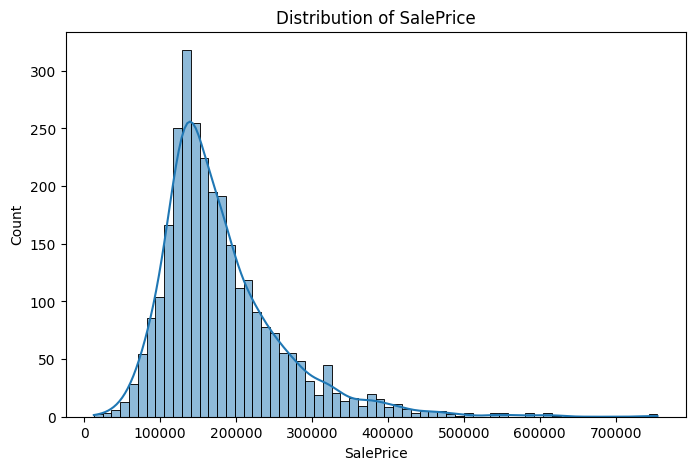

In [8]:
# y distribution

plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

In [9]:
df["SalePrice"].skew()

np.float64(1.7435000757376466)

This is a skewed distribution, so I make a log transformation.

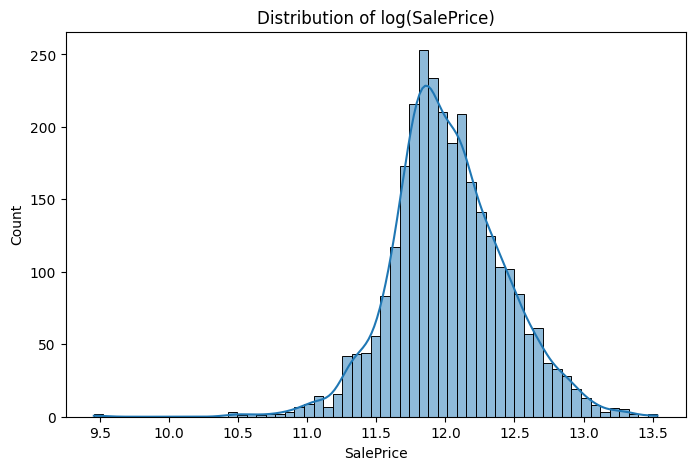

In [10]:
log_price = np.log1p(df["SalePrice"])

plt.figure(figsize=(8,5))
sns.histplot(log_price, kde=True)
plt.title("Distribution of log(SalePrice)")
plt.show()

In [11]:
log_price.skew()

np.float64(-0.014772659537224382)

In [12]:
# Define X and y

df["LogSalePrice"] = np.log1p(df["SalePrice"])
y = df["LogSalePrice"] 
X = df.drop(["SalePrice", "LogSalePrice"], axis=1)

In [13]:
# Null values?

missing = df.isnull().sum().sort_values(ascending=False)
missing.head(30)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 2         1
Electrical           1
Bsmt Unf SF          1
BsmtFin SF 1         1
Garage Area          1
Garage Cars          1
Total Bsmt SF        1
Overall Qual         0
Land Contour         0
Lot Shape            0
dtype: int64

In [14]:
# % of missing values

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "MissingValues": df.isnull().sum(),
    "Percent": missing_percent
})

missing_df = missing_df.sort_values("Percent", ascending=False)
missing_df

,MissingValues,Percent
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
...,...,...
Yr Sold,0,0.000000
Sale Type,0,0.000000
Sale Condition,0,0.000000
SalePrice,0,0.000000


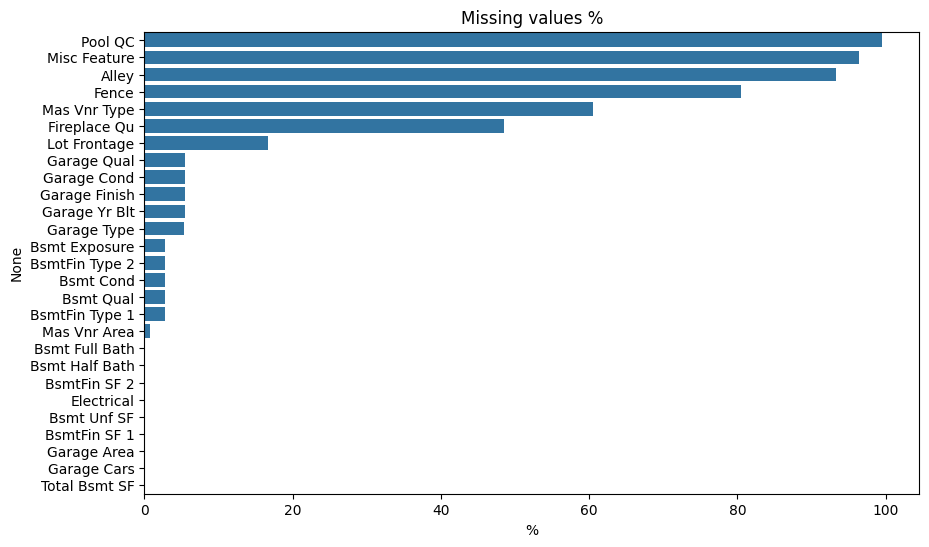

In [15]:
# Visualization

plt.figure(figsize=(10,6))

missing_df = missing_df[missing_df["Percent"] > 0]

sns.barplot(
    x=missing_df["Percent"], 
    y=missing_df.index
)

plt.title("Missing values %")
plt.xlabel("%")

plt.show()

For this specific dataset, some features are not actually filled because something is missing in the house (pool, for example).

So I must treat each feature with missing values differently.

In [16]:
# For houses without that feature -> Fill with None or zero

cols_none = ["Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu"]
for col in cols_none:
    df[col] = df[col].fillna("None")

# Garage variables
garage_cat = ["Garage Qual","Garage Cond","Garage Finish","Garage Type"]
for col in garage_cat:
    df[col] = df[col].fillna("None")

# Numerical variables garage
df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)
df["Garage Area"] = df["Garage Area"].fillna(0)
df["Garage Cars"] = df["Garage Cars"].fillna(0)

# Basement variables
bsmt_cat = ["Bsmt Exposure", "BsmtFin Type 2", "Bsmt Cond", "Bsmt Qual", "BsmtFin Type 1"]
for col in bsmt_cat:
    df[col] = df[col].fillna("None")

# Numerical variables basement
bsmt_num = ["Bsmt Full Bath", "Bsmt Half Bath", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF"]
for col in bsmt_num:
    df[col] = df[col].fillna(0)

df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)

In [17]:
# For features that cannot be filled with zero or None -> median and mode

df["Lot Frontage"] = df.groupby("Neighborhood")["Lot Frontage"].transform(
    lambda x: x.fillna(x.median())
)

df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

/home/asus/miniconda3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/asus/miniconda3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [18]:
# Null values?

missing = df.isnull().sum().sort_values(ascending=False)
missing.head(10)

Lot Frontage    3
PID             0
Order           0
MS SubClass     0
MS Zoning       0
Lot Area        0
Street          0
Alley           0
Lot Shape       0
Land Contour    0
dtype: int64

In [19]:
# For the last missing values I use the median

df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

In [20]:
# Remove useless columns

df = df.drop(["PID", "Order"], axis=1)

In [24]:
# Correlations with the target variable

corr_matrix = df.corr(numeric_only=True)
corr_target = corr_matrix["LogSalePrice"].sort_values(ascending=False)

corr_target.head(20)

LogSalePrice      1.000000
SalePrice         0.946304
Overall Qual      0.825645
Gr Liv Area       0.695863
Garage Cars       0.674878
Garage Area       0.650767
Total Bsmt SF     0.625622
Year Built        0.615485
1st Flr SF        0.602629
Year Remod/Add    0.586153
Full Bath         0.577335
TotRms AbvGrd     0.492580
Fireplaces        0.488945
Mas Vnr Area      0.442984
BsmtFin SF 1      0.411107
Lot Frontage      0.346551
Wood Deck SF      0.333320
Garage Yr Blt     0.327903
Open Porch SF     0.319938
Half Bath         0.305921
Name: LogSalePrice, dtype: float64

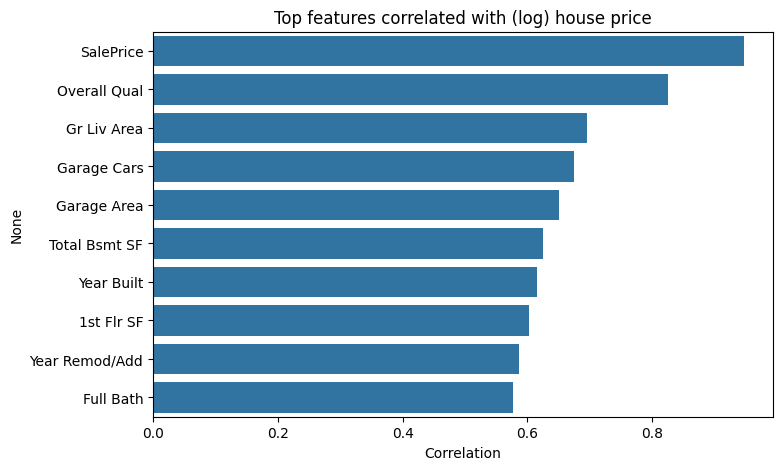

In [28]:
# Visulization

top_corr = corr_target[1:11]

plt.figure(figsize=(8,5))
sns.barplot(x=top_corr.values, y=top_corr.index)

plt.title("Top features correlated with (log) house price")
plt.xlabel("Correlation")

plt.show()

It seems that the most predictive features for the house prices are related to the overall quality, the living area and the garage properties.

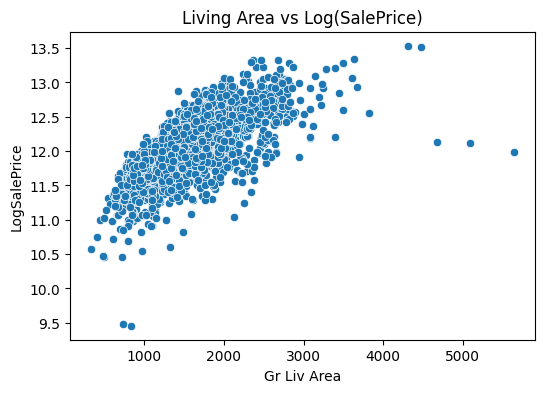

In [31]:
# Check for outliers in "Gr Liv Area"

plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df["Gr Liv Area"],
    y=df["LogSalePrice"]
)

plt.title("Living Area vs Log(SalePrice)")

plt.show()

These are houses with relatively low prices and high surface. I remove thm as they are few cases.

In [32]:
df = df[df["Gr Liv Area"] < 4000]

In [33]:
df.shape

(2925, 81)

Only 5 rows are removed.

## 2. Feature engineering

In [35]:
# Total surface of the house

df["TotalSF"] = (df["Total Bsmt SF"] + df["1st Flr SF"] + df["2nd Flr SF"])

In [36]:
# Age of the house

df["HouseAge"] = df["Yr Sold"] + df["Year Built"]

In [37]:
# Years since renovation

df["YearsSinceRemod"] = df["Yr Sold"] - df["Year Remod/Add"]

In [38]:
# Total bathrooms

df["TotalBath"] = (df["Full Bath"] + 0.5 * df["Half Bath"] + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"])

In [39]:
# Has garage?

df["HasGarage"] = (df["Garage Area"] > 0).astype(int)

In [40]:
# Has basement?

df["HasBasement"] = (df["Total Bsmt SF"] > 0).astype(int)

In [41]:
# Has fireplace?

df["HasFireplaces"] = (df["Fireplaces"] > 0).astype(int)

In [42]:
df.columns

Index(['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Gara

In [43]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)
corr_matrix["LogSalePrice"].sort_values(ascending=False).head(15)

LogSalePrice      1.000000
SalePrice         0.949299
Overall Qual      0.827560
TotalSF           0.818216
Gr Liv Area       0.711342
Garage Cars       0.674903
TotalBath         0.666448
Garage Area       0.653700
Total Bsmt SF     0.649055
1st Flr SF        0.620981
Year Built        0.616823
HouseAge          0.615195
Year Remod/Add    0.587849
Full Bath         0.575315
HasFireplaces     0.509447
Name: LogSalePrice, dtype: float64

Some of these new features are highly correlated to the target variable.

## 3. Prepara data for modeling

In [46]:
# Define X and y

y = df["LogSalePrice"]
X = df.drop(["SalePrice", "LogSalePrice"], axis=1)

In [48]:
# Separate numerical and categorical variables

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

print("Categorical features: ", len(cat_cols))
print("Numerical features: ", len(num_cols))

Categorical features:  43
Numerical features:  43


In [49]:
# OHE for categorical variables

X = pd.get_dummies(X)

X

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,True,False,False,False,False,True,False
2,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,...,False,False,False,True,False,False,False,False,True,False
4,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,37.0,7937,6,6,1984,1984,0.0,819.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2926,20,74.0,8885,5,5,1983,1983,0.0,301.0,324.0,...,False,False,False,True,False,False,False,False,True,False
2927,85,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2928,20,77.0,10010,5,5,1974,1975,0.0,1071.0,123.0,...,False,False,False,True,False,False,False,False,True,False


In [50]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(2340, 323)
(585, 323)


## 4. Models

### 4.1. Gradient Boosting

In [51]:
xgb_model = XGBRegressor(
    n_estimators=500,  
    learning_rate=0.05,
    max_depth=4,  
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [52]:
# Train

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [53]:
# Predict

y_pred = xgb_model.predict(X_test)

In [54]:
# Evaluate

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: ", rmse)

RMSE:  0.0926820093158513


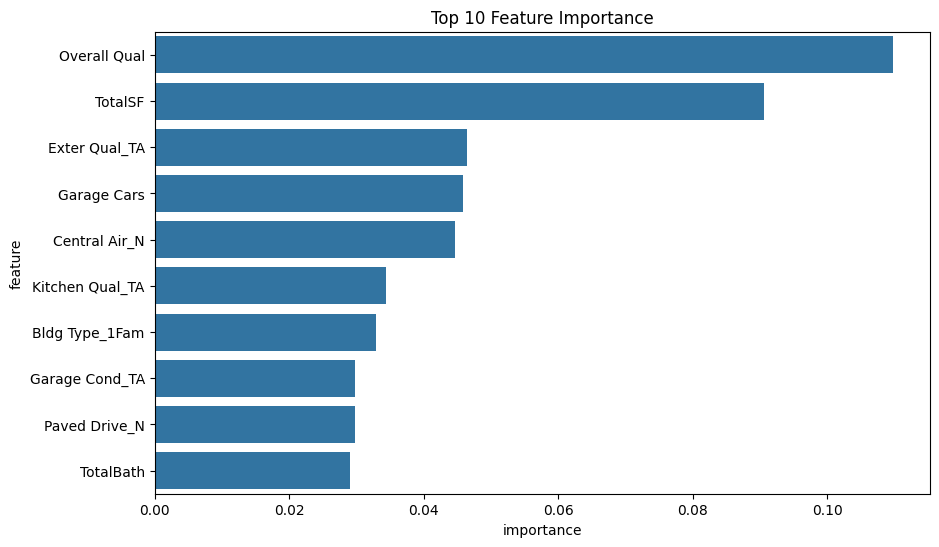

In [56]:
# Which ones are the most important features?

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Feature Importance")

plt.show()

### 4.2. Other models with cross-validation: XGBoost, LightGBM, CatBoost

In [59]:
# KFold cross validation

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [60]:
# Models

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# LightGBM
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# CatBoost
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

In [61]:
# Function for cross validation

def evaluate_model(model, X, y):

    scores = cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=kf, n_jobs=-1)
    rmse = -scores.mean()

    return rmse

In [63]:
# Evaluate models

models = {
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

results = {}

for name, model in models.items():

    rmse = evaluate_model(model, X_train, y_train)
    results[name] = rmse

    print(name, "RMSE:", rmse)

XGBoost RMSE: 0.12266604074229795
LightGBM RMSE: 0.12645455226556965
CatBoost RMSE: 0.12112931422242008


In [64]:
# Train the best model: CatBoost

best_model = cat_model
best_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)

In [65]:
y_pred = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", rmse_test)

Test RMSE: 0.088366363518518


In [66]:
# Important features 

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

In [67]:
importance

,feature,importance
36,TotalSF,21.387545
3,Overall Qual,16.227724
39,TotalBath,3.981368
15,Gr Liv Area,3.573537
4,Overall Cond,3.109365
...,...,...
272,Garage Type_None,0.000000
277,Garage Qual_Ex,0.000000
275,Garage Finish_RFn,0.000000
283,Garage Cond_Ex,0.000000


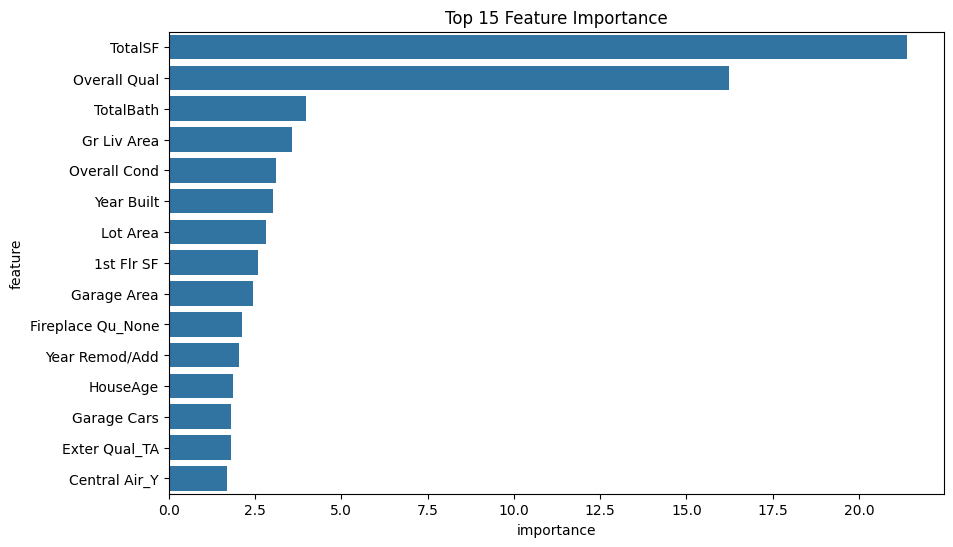

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importance")

plt.show()